In [87]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [88]:
df = pd.read_csv('water_HY.csv')
df.head()

,Date,Time,Muc_nuoc,Luu_luong
0,1/1/2008,1:00:00,130,612
1,1/1/2008,7:00:00,112,527
2,1/1/2008,13:00:00,115,542
3,1/1/2008,19:00:00,122,574
4,1/2/2008,1:00:00,118,556


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       101 non-null    object
 1   Time       101 non-null    object
 2   Muc_nuoc   101 non-null    int64 
 3   Luu_luong  101 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


In [90]:
df.isnull().sum()

Date         0
Time         0
Muc_nuoc     0
Luu_luong    0
dtype: int64

In [91]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.set_index('DateTime')
df.drop(['Date', 'Time'], axis = 1, inplace = True)

In [92]:
df.head()

,Muc_nuoc,Luu_luong
DateTime,,
2008-01-01 01:00:00,130,612
2008-01-01 07:00:00,112,527
2008-01-01 13:00:00,115,542
2008-01-01 19:00:00,122,574
2008-01-02 01:00:00,118,556


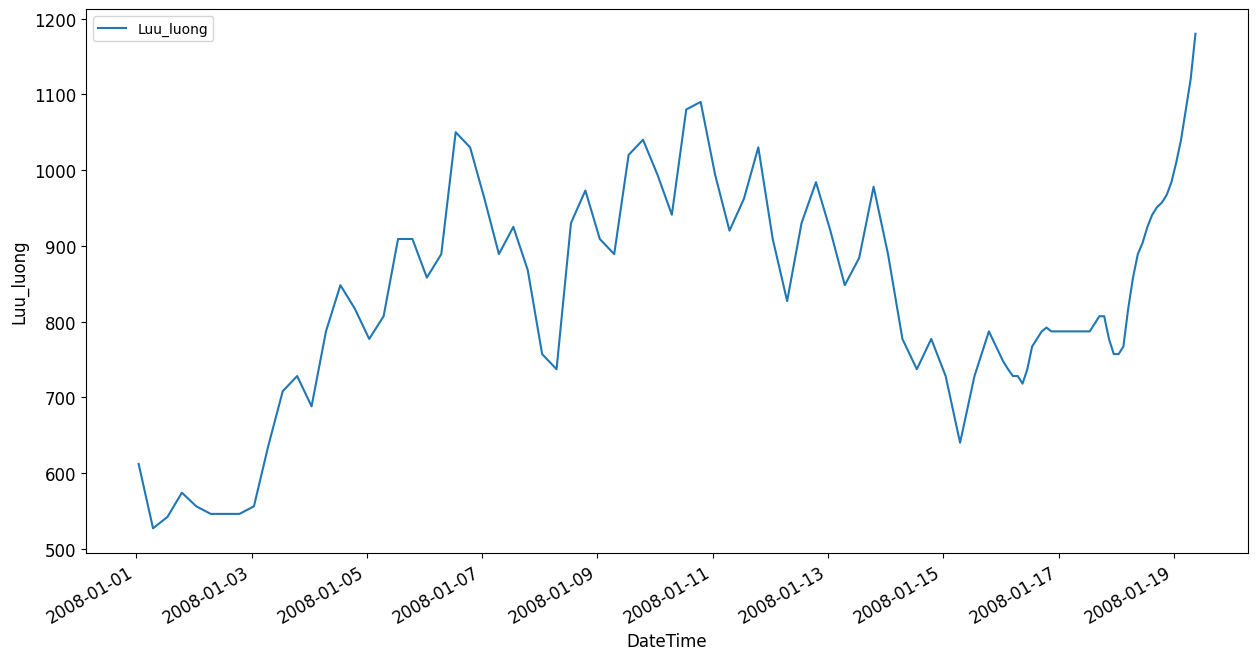

In [93]:
df.plot(y='Luu_luong', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Luu_luong', fontsize=12)
plt.show()

In [94]:
train_size = int(len(df) * 0.7)
train, test = df[:train_size].iloc[:, [-1]], df[train_size:].iloc[:, [-1]]

In [95]:
train, test

(                     Luu_luong
 DateTime                      
 2008-01-01 01:00:00        612
 2008-01-01 07:00:00        527
 2008-01-01 13:00:00        542
 2008-01-01 19:00:00        574
 2008-01-02 01:00:00        556
 ...                        ...
 2008-01-16 11:00:00        737
 2008-01-16 13:00:00        767
 2008-01-16 15:00:00        777
 2008-01-16 17:00:00        787
 2008-01-16 19:00:00        792
 
 [70 rows x 1 columns],
                      Luu_luong
 DateTime                      
 2008-01-16 21:00:00        787
 2008-01-16 23:00:00        787
 2008-01-17 01:00:00        787
 2008-01-17 03:00:00        787
 2008-01-17 05:00:00        787
 2008-01-17 07:00:00        787
 2008-01-17 09:00:00        787
 2008-01-17 11:00:00        787
 2008-01-17 13:00:00        787
 2008-01-17 15:00:00        797
 2008-01-17 17:00:00        807
 2008-01-17 19:00:00        807
 2008-01-17 21:00:00        777
 2008-01-17 23:00:00        757
 2008-01-18 01:00:00        757
 2008-01-18 03

In [96]:
train.shape, test.shape

((70, 1), (31, 1))

Text(0, 0.5, 'Luu_luong')

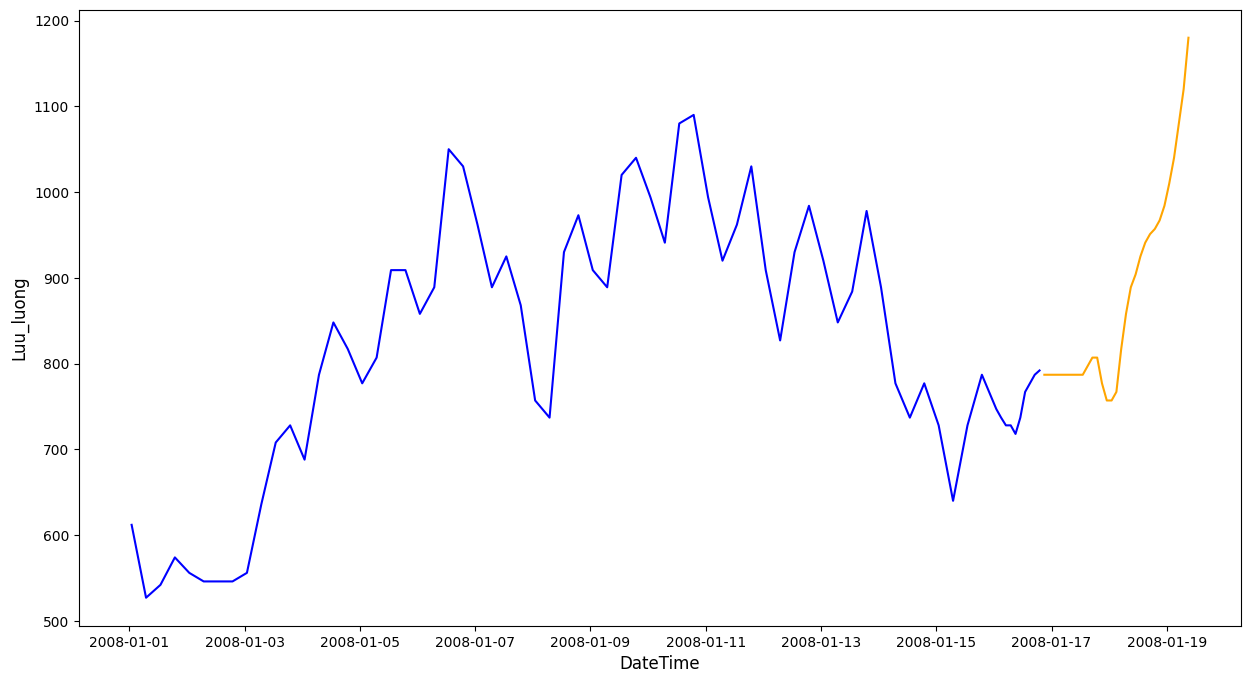

In [97]:
plt.figure(figsize = (15,8))
plt.plot(test.index, test['Luu_luong'], label = "test", color = 'orange')
plt.plot(train.index, train['Luu_luong'], label = "train" , color = 'blue')
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Luu_luong', fontsize=12)

In [98]:
scaler = MinMaxScaler()
train['Luu_luong'] = scaler.fit_transform(train)

In [99]:
test['Luu_luong'] = scaler.transform(test)

In [100]:
# Converting to numpy arrays
train_data = train.values
test_data = test.values

In [101]:
timesteps=5

In [102]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] for i in range(0,len(train_data)-timesteps+1)])[:,:,0]
train_data_timesteps.shape

(66, 5)

In [103]:
test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] for i in range(0,len(test_data)-timesteps+1)])[:,:,0]
test_data_timesteps.shape

(27, 5)

In [104]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(66, 4) (66, 1)
(27, 4) (27, 1)


In [105]:
model = SVR(kernel='rbf',gamma=0.5, C=10, epsilon = 0.05)

In [106]:
model.fit(x_train, y_train[:,0])

SVR(C=10, epsilon=0.05, gamma=0.5)

In [107]:
y_train_pred = model.predict(x_train).reshape(-1,1)
y_test_pred = model.predict(x_test).reshape(-1,1)

print(y_train_pred.shape, y_test_pred.shape)

(66, 1) (27, 1)


In [108]:
# Scaling the predictions
y_train_pred = scaler.inverse_transform(y_train_pred)
y_test_pred = scaler.inverse_transform(y_test_pred)

print(len(y_train_pred), len(y_test_pred))

66 27


In [109]:
# Scaling the original values
y_train = scaler.inverse_transform(y_train)
y_test = scaler.inverse_transform(y_test)

print(len(y_train), len(y_test))

66 27


In [110]:
train_timestamps = train.index[timesteps-1:]
test_timestamps = test.index[timesteps-1:]

print(len(train_timestamps), len(test_timestamps))

66 27


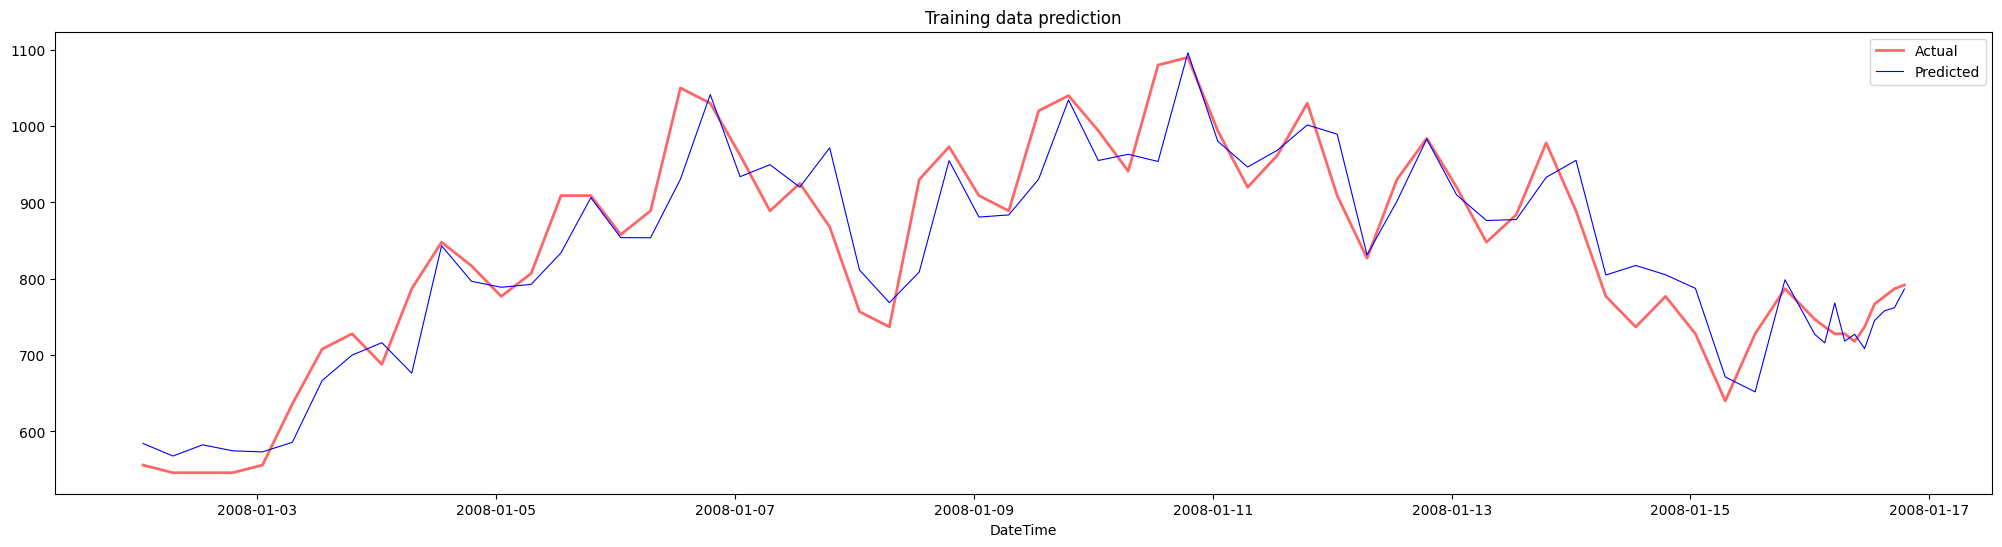

In [111]:
plt.figure(figsize=(25,6))
plt.plot(train_timestamps, y_train, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(train_timestamps, y_train_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('DateTime')
plt.title("Training data prediction")
plt.show()

In [112]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_train, y_train_pred)
print('MAPE for training data: ', mape*100, '%')

MAPE for training data:  4.228275849627751 %


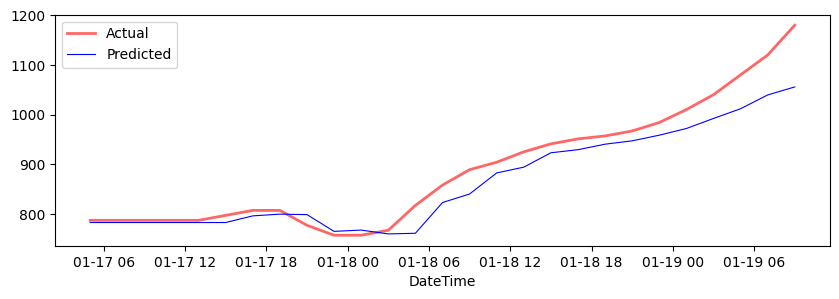

In [113]:
plt.figure(figsize=(10,3))
plt.plot(test_timestamps, y_test, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(test_timestamps, y_test_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('DateTime')
plt.show()

In [114]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_test_pred)
print('MAPE for training data: ', mape*100, '%')

MAPE for training data:  2.89687338898364 %


In [123]:
y_test_flat = y_test.flatten()
y_test_pred_flat = y_test_pred.flatten()

# Tạo DataFrame với chỉ số là test_timestamps
df = pd.DataFrame({'Actual': y_test_flat, 'Predicted': y_test_pred_flat}, index=test_timestamps)

# Hiển thị DataFrame
df

,Actual,Predicted
DateTime,,
2008-01-17 05:00:00,787.0,782.597346
2008-01-17 07:00:00,787.0,782.597346
2008-01-17 09:00:00,787.0,782.597346
2008-01-17 11:00:00,787.0,782.597346
2008-01-17 13:00:00,787.0,782.597346
2008-01-17 15:00:00,797.0,782.597346
2008-01-17 17:00:00,807.0,795.982476
2008-01-17 19:00:00,807.0,799.461232
2008-01-17 21:00:00,777.0,798.491981
